In [1]:
import matplotlib.pyplot as plt
# plt.style.use('seaborn-v0_8')
plt.style.use('ggplot')
import matplotlib.pylab as plt
import pickle as pkl
import numpy as np

['text_length', 'num_unique_words', 'avg_word_length', 'num_stopwords', 'num_punctuation', 'num_format', 'num_adjectives_adverbs']


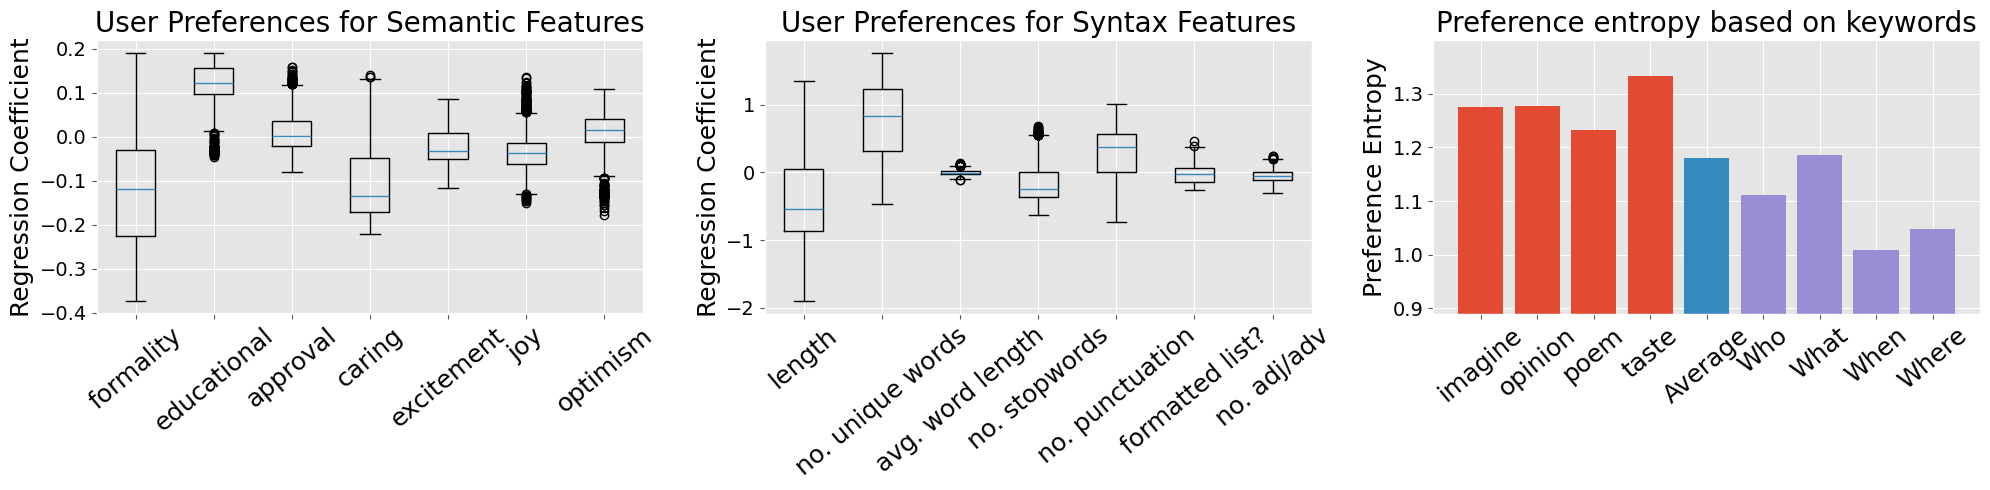

In [5]:
plt.rcParams["figure.figsize"] = (20,5)

fig, axs = plt.subplots(1,3)

with open("semantic_weights.pkl", "rb") as f:
    (feature_list, test_weights) = pkl.load(f)

data = [test_weights[:,i] for i in range(test_weights.shape[-1])]
axs[0].boxplot(data)
axs[0].set_xticks(np.arange(test_weights.shape[-1])+1, feature_list, fontsize=18, rotation=40)
# axs[0].set_xlabel("Response Feature", fontsize=18)
axs[0].set_ylabel("Regression Coefficient", fontsize=18, color="k")
axs[0].set_title("User Preferences for Semantic Features", fontsize=20)
axs[0].tick_params("y", labelsize=14)


with open("syntax_weights.pkl", "rb") as f:
    (feature_list, test_weights) = pkl.load(f)

print(feature_list)

f_map = {
    'text_length': "length",
    'num_unique_words': "no. unique words",
    'avg_word_length': "avg. word length",
    'num_stopwords': "no. stopwords",
    'num_punctuation': "no. punctuation",
    'num_format': "formatted list?",
    'num_adjectives_adverbs': "no. adj/adv"
}

data = [test_weights[:,i] for i in range(test_weights.shape[-1])]
axs[1].boxplot(data)
axs[1].set_xticks(np.arange(test_weights.shape[-1])+1, [f_map[f] for f in feature_list], fontsize=18, rotation=40)
# axs[1].set_xlabel("Response Feature", fontsize=18)
axs[1].set_ylabel("Regression Coefficient", fontsize=18, color="k")
axs[1].set_title("User Preferences for Syntax Features", fontsize=20)
axs[1].tick_params("y", labelsize=14)

# SAVE PLOT DATA
with open("prompt_entropy.pkl", "rb") as f:
    (plot_data, plot_labels) = pkl.load(f)

avgs = [np.mean(d) for d in plot_data]
axs[2].bar(plot_labels[:4], avgs[:4])
axs[2].bar(plot_labels[4], avgs[4])
axs[2].bar(plot_labels[5:], avgs[5:])

axs[2].set_xticks(np.arange(len(avgs)), plot_labels, rotation=40, size=18)
# axs[2].set_xlabel("Keyword", fontsize=18)
axs[2].set_ylabel("Preference Entropy", fontsize=18, color="k")
axs[2].tick_params("y", labelsize=14)
axs[2].set_ylim(0.89, None)
axs[2].set_title("Preference entropy based on keywords", fontsize=20)

for i in range(3):
    axs[i].tick_params("y", labelcolor="k")
    axs[i].tick_params("x", labelcolor="k")

fig.tight_layout()
plt.savefig("../plots/syn_sem_ent.png", bbox_inches="tight", dpi=300)
plt.show()